# 04 — A BERT-like Transformer for sentiment analysis

> **Notebook 4 of 6** in the *Natural Language Processing from Scratch* series.

## What you will learn
- How to fine-tune a **pre-trained BERT** model from Hugging Face on IMDB.
- How to write your **own training loop** — no `Trainer`, no `Lightning` — to deeply
  understand every step (forward, loss, backward, optimizer step, scheduler).
- How to handle **gradient accumulation** to train with effective batch sizes that
  do not fit in GPU memory.
- How to diagnose convergence by **overfitting a single batch** as a sanity check.

## Prerequisites
[Notebook 03](03_self_attention.ipynb) — self-attention.

## Dataset
IMDB — 20k / 5k train / validation reviews.

## Estimated runtime
~30 minutes on a Colab T4 GPU (3–5 epochs).

## Reference
*See `references/05_bert.pdf` (Devlin et al., 2018).*


## Exercise brief

Train and measure the accuracy of a **BERT-based** binary classifier on IMDB
(20k / 5k train / val).

### Required
- Implement your **own training loop** (no `Trainer`, no Lightning).
- Verify the model can **overfit a single batch** as a sanity check.
- Implement **gradient accumulation**.

### Tips
- BERT typically learns this task in **3–5 epochs**. If you need more than 5 epochs
  to reach 80% accuracy, revisit your hyper-parameters.
- **Out-of-memory?** Using `bfloat16` mixed precision roughly **doubles** the batch size.

### Optional
- Cross-check your loop against Hugging Face's `Trainer`. You must still ship your
  own loop, but this is a useful debugging aid.


## Fixing the random seed (for reproducibility)


In [1]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.9 MB/s eta 0:00:00


In [ ]:
# instalando Neptune (opcional - descomente se for usar)
# !pip install -q install transformers  neptune-client==0.9.8

     |████████████████████████████████| 2.9 MB 4.0 MB/s 
     |████████████████████████████████| 231 kB 61.8 MB/s 
     |████████████████████████████████| 829 kB 68.0 MB/s 
     |████████████████████████████████| 52 kB 1.7 MB/s 
     |████████████████████████████████| 180 kB 74.3 MB/s 
     |████████████████████████████████| 63 kB 2.5 MB/s 
     |████████████████████████████████| 895 kB 61.0 MB/s 
     |████████████████████████████████| 3.3 MB 15.7 MB/s 
     |████████████████████████████████| 636 kB 61.9 MB/s 
     |████████████████████████████████| 56 kB 7.0 MB/s 
     |████████████████████████████████| 67 kB 6.6 MB/s 
     |████████████████████████████████| 129 kB 76.0 MB/s 


In [2]:
import random
import torch
from collections import Counter
import gensim
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import numpy as np
from transformers import AutoTokenizer
from transformers import BertModel

import logging


In [3]:
if torch.cuda.is_available():
   dev = "cuda:0"
   print(torch. cuda. get_device_name(dev))
else:
   dev = "cpu"
print(dev)
device = torch.device(dev)

Tesla T4
cuda:0


In [4]:
random.seed(123)
np.random.seed(123)
torch.manual_seed(123)

## Step 1 — Preparing the data


First we download the IMDB dataset:


In [5]:
!wget -nc http://files.fast.ai/data/aclImdb.tgz
!tar -xzf aclImdb.tgz

--2026-05-03 12:06:21--  http://files.fast.ai/data/aclImdb.tgz
Resolving files.fast.ai (files.fast.ai)... 104.26.2.19, 172.67.69.159, 104.26.3.19, ...
Connecting to files.fast.ai (files.fast.ai)|104.26.2.19|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.fast.ai/data/aclImdb.tgz [following]
--2026-05-03 12:06:21--  https://files.fast.ai/data/aclImdb.tgz
Connecting to files.fast.ai (files.fast.ai)|104.26.2.19|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 145982645 (139M) [application/x-gtar-compressed]
Saving to: ‘aclImdb.tgz’

aclImdb.tgz         100%[===================>] 139.22M   132MB/s    in 1.1s    

2026-05-03 12:06:23 (132 MB/s) - ‘aclImdb.tgz’ saved [145982645/145982645]



## Loading the dataset

Artificial train / validation split — 20k training reviews, 5k validation reviews.


In [6]:
import os

max_valid = 5000

def load_texts(folder):
    texts = []
    for path in os.listdir(folder):
        with open(os.path.join(folder, path)) as f:
            texts.append(f.read())
    return texts

x_train_pos = load_texts('aclImdb/train/pos')
x_train_neg = load_texts('aclImdb/train/neg')
x_test_pos = load_texts('aclImdb/test/pos')
x_test_neg = load_texts('aclImdb/test/neg')

x_train = x_train_pos + x_train_neg
x_test = x_test_pos + x_test_neg
y_train = [True] * len(x_train_pos) + [False] * len(x_train_neg)
y_test = [True] * len(x_test_pos) + [False] * len(x_test_neg)

# Embaralhamos o treino para depois fazermos a divisão treino/valid.
c = list(zip(x_train, y_train))
random.shuffle(c)
x_train, y_train = zip(*c)

x_valid = x_train[-max_valid:]
y_valid = y_train[-max_valid:]
x_train = x_train[:-max_valid]
y_train = y_train[:-max_valid]

print(len(x_train), 'amostras de treino.')
print(len(x_valid), 'amostras de desenvolvimento.')
print(len(x_test), 'amostras de teste.')

print('3 primeiras amostras treino:')
for x, y in zip(x_train[:3], y_train[:3]):
    print(y, x[:100])

print('3 últimas amostras treino:')
for x, y in zip(x_train[-3:], y_train[-3:]):
    print(y, x[:100])

print('3 primeiras amostras validação:')
for x, y in zip(x_valid[:3], y_test[:3]):
    print(y, x[:100])

print('3 últimas amostras validação:')
for x, y in zip(x_valid[-3:], y_valid[-3:]):
    print(y, x[:100])

20000 amostras de treino.
5000 amostras de desenvolvimento.
25000 amostras de teste.
3 primeiras amostras treino:
False From the creators of Shrek.. OK, that grabbed my attention.<br /><br />Well the creators of Shre
False Would anyone really watch this RUBBISH if it didn't contain little children running around nude? Fro
True In what is a truly diverse cast, this show hits it's stride on FOX. It is the kind of sitcom that gr
3 últimas amostras treino:
False The Lack of content in this movie amazed me the most. First i though that people was going to compar
True It is not every film's job to stimulate you superficially. I will take an ambitious failure over a m
True I would not hesitate to put this adaptation of 'Death Trap" in a top 5 list of the best stage-to-mov
3 primeiras amostras validação:
True It's funny how your life can change in a second... To attend ''The Waterdance'' for the first time i
True I'm not sure how I missed this one when it first came out, but I am glad to h

## Loading BERT and inspecting its tokenization / embedding pipeline


In [7]:


tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
encoded_input = tokenizer("Hello, I'm a single sentence!")
print(encoded_input)
print("Deconding sentence: ", tokenizer.decode(encoded_input["input_ids"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [101, 8667, 117, 146, 112, 182, 170, 1423, 5650, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
Deconding sentence:  [CLS] Hello, I ' m a single sentence! [SEP]


## Dataset and DataLoader


In [8]:
# recebe os textos , tokeniza e gera os embeddings pela sentença inteira
# basedo no tutorial: https://pytorch.org/tutorials/beginner/text_sentiment_ngrams_tutorial.html

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, sentences,
                 labels,
                 model_tokens = 'bert-base-uncased'):
        super().__init__()

        self.tokenizer = AutoTokenizer.from_pretrained(model_tokens)

        self.tokens = self.tokenizer(sentences,
                                     padding="max_length",
                                     truncation=True)["input_ids"]

        self.mask_attention = self.tokenizer(sentences,
                                             padding="max_length",
                                             truncation=True)["attention_mask"]
        self.labels = labels


    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

      #indexs, masked_indexs, label
      return torch.tensor(self.tokens[idx]).long(),\
             torch.tensor(self.mask_attention[idx]).long(),\
             torch.tensor(self.labels[idx]).long()

## Review classifier model

Define your fine-tuning head on top of BERT below.


In [ ]:
### SEU CÓDIGO AQUI


## Training loop
> **Gradient accumulation recipe:**

> 1) Run forward + backward for `n` steps **without** stepping the optimizer.

> 2) After the `n`-th step, call `optimizer.step()` and `optimizer.zero_grad()`.


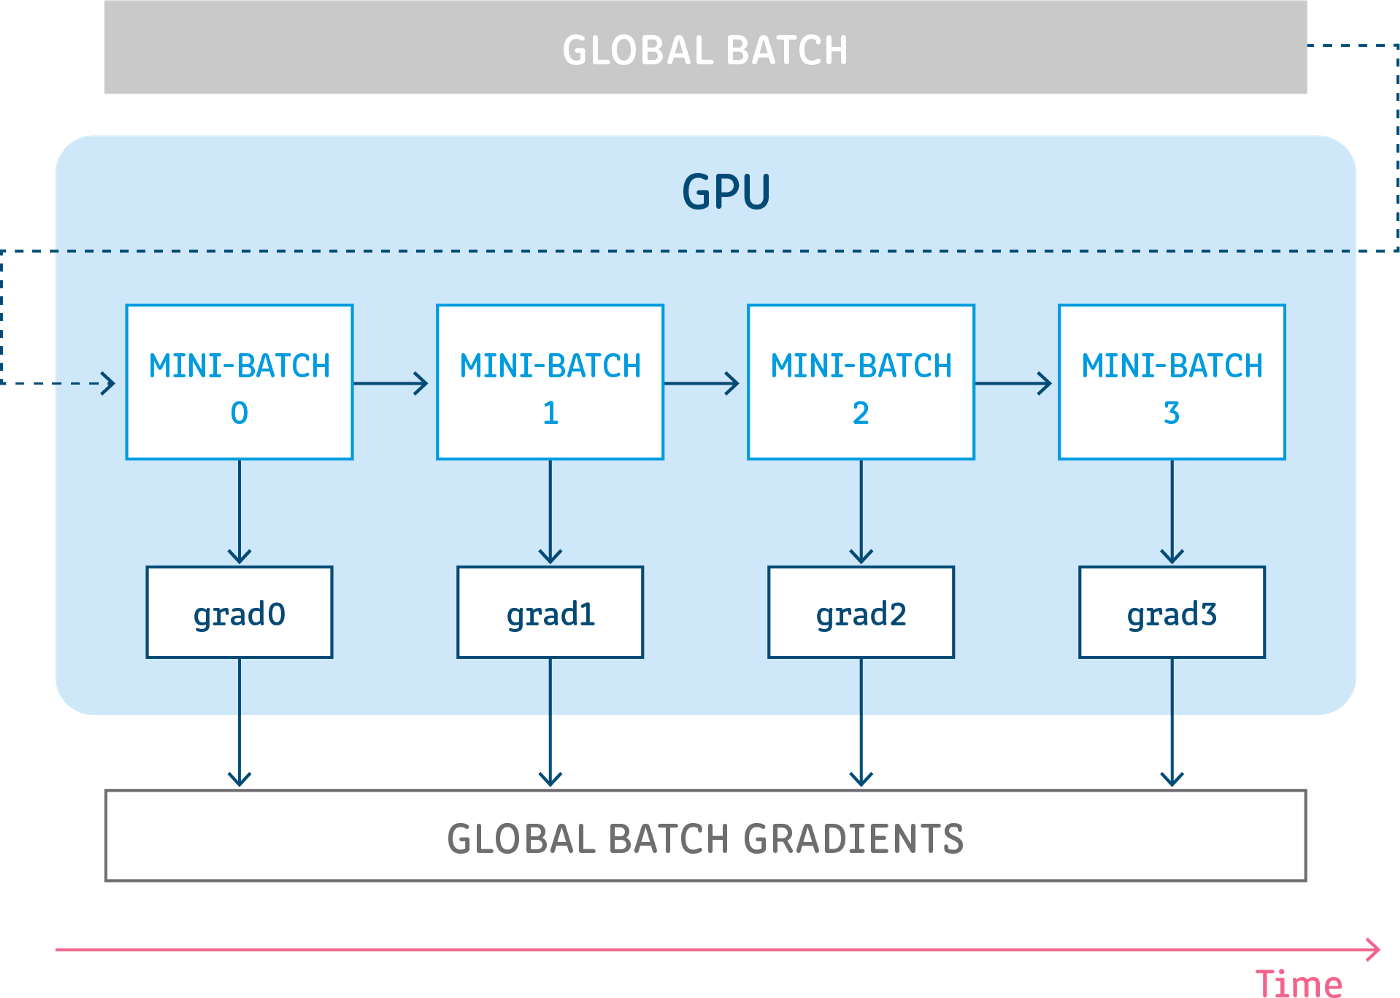

Define your training and validation loop below.


In [ ]:
### SEU CÓDIGO AQUI

## Overfitting sanity check


Verify that the model can overfit a single batch.


In [ ]:
lr = 1e-4#@param {type: "number"}
bs = 5#@param {type: "integer"}
bs_acc_step = 2
max_epochs = 7#@param {type: "integer"}
num_class = 2#@param {type: "integer"}

params = {
    'lr': lr,
    'bs': bs,
    'max_epochs': max_epochs,
    'num_class': num_class,
    'bs_acc_step':bs_acc_step
}

In [ ]:

# Datasets
train_dataset = IMDBDataset(list(x_train[:100]), list(y_train[:100]))

# Dataloaders
loader_train =  DataLoader(train_dataset, batch_size=params['bs'], shuffle=True)
loader_val = DataLoader(train_dataset, batch_size=params['bs'], shuffle=True)
loader_test = DataLoader(train_dataset, batch_size=params['bs'], shuffle=True)

Downloading:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/455k [00:00<?, ?B/s]

In [ ]:
x_train_, x_train_mask, y_train_ = next(iter(DataLoader(train_dataset, batch_size=5)))
print("\nDimensões dos dados de um minibatch:", x_train_.size())
print("\nDimensões dos dados de um minibatch:", y_train_.size())


Dimensões dos dados de um minibatch: torch.Size([5, 512])

Dimensões dos dados de um minibatch: torch.Size([5])


In [ ]:
### Treino do overfitting


### SEU CÓDIGO AQUI

https://app.neptune.ai/mirelle/exercicio-9/e/EX5-39


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


evaluating model...
Done!
Época: 0/6 Train Loss: 0.069618 Valid Acc: 0.590000
evaluating model...
Done!
Época: 1/6 Train Loss: 0.062534 Valid Acc: 0.790000
evaluating model...
Done!
Época: 2/6 Train Loss: 0.036979 Valid Acc: 0.910000
evaluating model...
Done!
Época: 3/6 Train Loss: 0.018512 Valid Acc: 1.000000
evaluating model...
Done!
Época: 4/6 Train Loss: 0.004677 Valid Acc: 1.000000
evaluating model...
Done!
Época: 5/6 Train Loss: 0.004158 Valid Acc: 1.000000
evaluating model...
Done!
Época: 6/6 Train Loss: 0.012912 Valid Acc: 1.000000


## Training — `bert-base-uncased`


In [ ]:
lr = 1e-4#@param {type: "number"}
bs = 10#@param {type: "integer"}
bs_acc_step = 2
max_epochs = 5#@param {type: "integer"}
num_class = 2#@param {type: "integer"}

params = {
    'lr': lr,
    'bs': bs,
    'max_epochs': max_epochs,
    'num_class': num_class,
    'bs_acc_step':bs_acc_step
}

In [ ]:
# Datasets
train_dataset = IMDBDataset(list(x_train), list(y_train))
val_dataset = IMDBDataset(list(x_valid), list(y_valid), model_tokens = "bert-base-uncased")
test_dataset = IMDBDataset(list(x_test), list(y_test), model_tokens = "bert-base-uncased")
# Dataloaders
loader_train =  DataLoader(train_dataset, batch_size=params['bs'], shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=params['bs'], shuffle=True)
loader_test = DataLoader(test_dataset, batch_size=params['bs'], shuffle=True)

In [ ]:
x_train_, x_train_mask, y_train_ = next(iter(DataLoader(train_dataset, batch_size=5)))
print("\nDimensões dos dados de um minibatch:", x_train_.size())
print("\nDimensões dos dados de um minibatch:", y_train_.size())


Dimensões dos dados de um minibatch: torch.Size([5, 512])

Dimensões dos dados de um minibatch: torch.Size([5])


In [ ]:
### Treino completo
# Esse laço demora. Para 1 época, demorou 35 min. Todas demorou ~4h

### SEU CÓDIGO AQUI

https://app.neptune.ai/mirelle/exercicio-9/e/EX5-40


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


evaluating model...
Done!
Época: 0/4 Train Loss: 0.012488 Valid Acc: 0.913200
evaluating model...
Done!
Época: 1/4 Train Loss: 0.005850 Valid Acc: 0.928800
evaluating model...
Done!
Época: 2/4 Train Loss: 0.002671 Valid Acc: 0.931600
evaluating model...
Done!
Época: 3/4 Train Loss: 0.001333 Valid Acc: 0.933400
evaluating model...
Done!
Época: 4/4 Train Loss: 0.001009 Valid Acc: 0.929800


In [ ]:
### Avalie seu modelo em teste e retorne a acurácia

### SEU CÓDIGO AQUI